# 03 — Feature Engineering

## Objective

Create predictors for **next-day streamflow** from the real 2020 Squamish dataset. The EDA showed that same-day precipitation alone does not explain river response, so lagged and rolling variables represent short-term environmental memory.

The forecast is assumed to be made at the **end of the current day**. Therefore today's climate and streamflow observations are available, while tomorrow's streamflow is used only as the target.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from features import build_features

merged_path = ROOT / "data" / "processed" / "hydroclimate_merged.csv"
df = pd.read_csv(merged_path, parse_dates=["date"])
print(df.shape)
df.head()

(366, 4)


,date,mean_temp_c,precipitation_mm,streamflow_cms
0,2020-01-01,5.8,13.0,135.0
1,2020-01-02,2.3,10.8,135.0
2,2020-01-03,4.1,15.0,131.0
3,2020-01-04,5.5,6.0,234.0
4,2020-01-05,3.2,3.2,140.0


## 1. Data quality and short-gap interpolation

The merged data has four missing temperatures and nine missing precipitation values. Linear interpolation is limited to at most three consecutive **internal** observations. Longer gaps remain missing and are removed from the modeling table rather than filled with unsupported estimates.

This is a retrospective one-year study. Because linear interpolation can use the next observed climate value, a truly operational forecast would replace this step with a past-only imputation rule.

In [2]:
df.isna().sum()

date                0
mean_temp_c         4
precipitation_mm    9
streamflow_cms      0
dtype: int64

In [3]:
features = build_features(df, persist=False)
print(features.shape)
features.head()

Modeling rows: 349
Date range: 2020-01-08 to 2020-12-30
(349, 15)


,date,mean_temp_c,precipitation_mm,streamflow_cms,precip_lag1,precip_3day,precip_7day,temp_3day_mean,temp_7day_mean,streamflow_lag1,streamflow_lag3,streamflow_7day_mean,month,day_of_year,target_next_day_streamflow
0,2020-01-08,1.5,3.500000,137.0,3.600000,8.200000,43.200000,1.400000,2.757143,142.0,140.0,148.000000,1,8,85.3
1,2020-01-09,0.6,3.400000,85.3,3.500000,10.500000,35.800000,1.200000,2.514286,137.0,119.0,148.285714,1,9,69.5
2,2020-01-10,0.1,4.685714,69.5,3.400000,11.585714,25.485714,0.733333,1.942857,85.3,142.0,141.185714,1,10,61.2
3,2020-01-11,0.9,5.971429,61.2,4.685714,14.057143,25.457143,0.533333,1.285714,69.5,137.0,132.400000,1,11,56.3
4,2020-01-12,-1.3,7.257143,56.3,5.971429,17.914286,29.514286,-0.100000,0.642857,61.2,85.3,107.714286,1,12,61.7


## 2. Engineered variables

- `precip_lag1`: previous-day precipitation
- `precip_3day`, `precip_7day`: recent precipitation totals ending today
- `temp_3day_mean`, `temp_7day_mean`: recent temperature averages ending today
- `streamflow_lag1`, `streamflow_lag3`: river persistence from prior days
- `streamflow_7day_mean`: prior seven-day flow average; the series is shifted before rolling
- `month`, `day_of_year`: seasonal position
- `target_next_day_streamflow`: tomorrow's flow, created with `shift(-1)`

No feature uses tomorrow's streamflow. Rows are sorted before shifting and rolling.

In [4]:
feature_columns = [
    "streamflow_cms", "mean_temp_c", "precipitation_mm", "precip_lag1",
    "precip_3day", "precip_7day", "temp_3day_mean", "temp_7day_mean",
    "streamflow_lag1", "streamflow_lag3", "streamflow_7day_mean",
    "month", "day_of_year"
]

features[["date", *feature_columns, "target_next_day_streamflow"]].head(10)

,date,streamflow_cms,mean_temp_c,precipitation_mm,precip_lag1,precip_3day,precip_7day,temp_3day_mean,temp_7day_mean,streamflow_lag1,streamflow_lag3,streamflow_7day_mean,month,day_of_year,target_next_day_streamflow
0,2020-01-08,137.0,1.5,3.500000,3.600000,8.200000,43.200000,1.400000,2.757143,142.0,140.0,148.000000,1,8,85.3
1,2020-01-09,85.3,0.6,3.400000,3.500000,10.500000,35.800000,1.200000,2.514286,137.0,119.0,148.285714,1,9,69.5
2,2020-01-10,69.5,0.1,4.685714,3.400000,11.585714,25.485714,0.733333,1.942857,85.3,142.0,141.185714,1,10,61.2
3,2020-01-11,61.2,0.9,5.971429,4.685714,14.057143,25.457143,0.533333,1.285714,69.5,137.0,132.400000,1,11,56.3
4,2020-01-12,56.3,-1.3,7.257143,5.971429,17.914286,29.514286,-0.100000,0.642857,61.2,85.3,107.714286,1,12,61.7
5,2020-01-22,161.0,1.7,11.100000,37.400000,68.900000,137.600000,2.666667,-0.928571,167.0,41.9,72.200000,1,22,182.0
6,2020-01-23,182.0,2.3,51.100000,11.100000,99.600000,176.300000,2.566667,0.571429,161.0,106.0,87.557143,1,23,270.0
7,2020-01-24,270.0,4.5,20.900000,51.100000,83.100000,197.200000,2.833333,1.828571,182.0,167.0,105.285714,1,24,222.0
8,2020-01-25,222.0,4.0,2.800000,20.900000,74.800000,173.000000,3.600000,2.800000,270.0,161.0,138.200000,1,25,158.0
9,2020-01-26,158.0,5.3,11.900000,2.800000,35.600000,155.600000,4.600000,3.442857,222.0,182.0,164.271429,1,26,166.0


## 3. Correlation with next-day streamflow

Correlation describes linear association, not causation. Related rolling and lagged variables are also correlated with one another, so these values should not be interpreted as isolated effects.

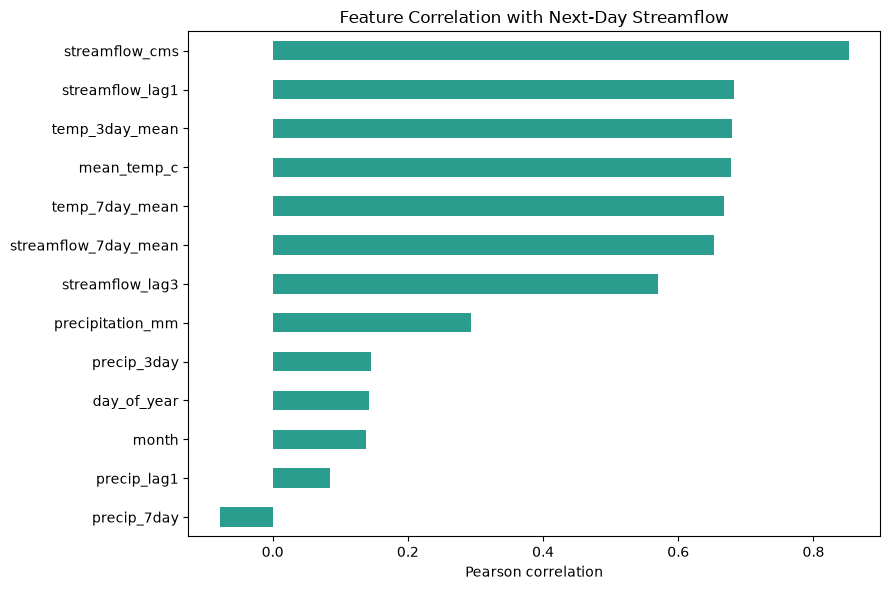

,correlation
streamflow_cms,0.851906
streamflow_lag1,0.682825
temp_3day_mean,0.679774
mean_temp_c,0.677916
temp_7day_mean,0.667735
streamflow_7day_mean,0.652742
streamflow_lag3,0.569874
precipitation_mm,0.293759
precip_3day,0.144912
day_of_year,0.142411


In [5]:
correlations = (
    features[feature_columns + ["target_next_day_streamflow"]]
    .corr()["target_next_day_streamflow"]
    .drop("target_next_day_streamflow")
    .sort_values()
)

ax = correlations.plot(kind="barh", figsize=(9, 6), color="#2a9d8f")
ax.set(title="Feature Correlation with Next-Day Streamflow", xlabel="Pearson correlation")
plt.tight_layout()
plt.show()
correlations.sort_values(ascending=False).to_frame("correlation")

## 4. Save the modeling table

The saved file is a derived artifact. Running `python src/run_all.py` recreates it from the processed clean files.

In [6]:
output_path = ROOT / "data" / "processed" / "hydroclimate_features.csv"
features.to_csv(output_path, index=False)
print(f"Saved {len(features)} rows to {output_path}")

Saved 349 rows to C:\ClimateFlow-BC\zip\ClimateFlow-BC-Final\data\processed\hydroclimate_features.csv


## Takeaway

The features formalize the river's short-term persistence, accumulated precipitation, recent temperature, and seasonality. They support prediction, but neither correlation nor model importance establishes an environmental cause.